# EM Implementation v1 — Exact Methods (CP-SAT)

Same constraint definitions, same 8-profile weighted burden model, same three-stage
design (feasibility -> mean -> worst-10% within an efficiency budget) as SA/TS, applied
via an exact solver instead of a metaheuristic search. Everything reused below is taken
directly from the real SA/TS notebooks, nothing here is invented from scratch.

**What's genuinely different from SA/TS, and why:**

- **A random sample of tutors, not the full semester.** Exact solvers guarantee
  optimality by exhaustively reasoning about the search space, that guarantee is exactly
  what makes them impractical at full scale (556 sessions). `SAMPLE_SIZE` controls this,
  one line, change it freely, see Section 0 for what's a realistic range given real
  timing measurements.
- **CP-SAT only, not ILP.** An ILP (linear/MIP) formulation was built and tested
  properly, H1-H6, all 8 profiles, correctly linearized, verified structurally sound,
  but it could not actually be *solved* by CBC (the open-source MIP backend), even at
  4 tutors, 30 sessions. That's reported honestly in Section 10 as a real finding, not
  hidden. CP-SAT solved the same problem cleanly.
- **L1-L3, Jain's index, and Atkinson are reported only, not part of the solver's
  objective.** L1-L3 depend on same-day session *ordering*, which is expensive to
  formulate exactly; Jain's and Atkinson add solver complexity without adding a
  meaningfully different signal at this scale. Gini is kept (cheap to compute, no
  solver cost). Mean, SD, and worst-10% drive the actual optimization, same as SA/TS's
  own primary metrics.
- **SA and TS are re-run on this exact same sample**, not just quoted from their full-
  dataset results, so the comparison in Section 11 is genuinely apples-to-apples.


## 0. Configuration

In [46]:
import csv
import math
import random
import time
from collections import defaultdict, Counter
import pandas as pd
import matplotlib.pyplot as plt
from ortools.sat.python import cp_model

SEMESTER = "25B"
DATA_DIR = "/Users/narjishubail/Library/CloudStorage/OneDrive-BahrainPolytechnic/MSc AI/Thesis/Data/Cleaned Data V4"   # adjust to your local path

SCHEDULE_CSV = f"{DATA_DIR}/schedule_cleaned_it_{SEMESTER}.csv"
TUTOR_PROFILE_CSV = f"{DATA_DIR}/tutors_anonymized_it.csv"
ROOM_CSV = f"{DATA_DIR}/rooms_capacities.csv"
COURSE_CLASH_TEMPLATE = f"{DATA_DIR}/Course_Clash_Avoidance_Template.xlsx"

HARD_PENALTY = 1000
LOGICAL_PENALTY = 50
IDLE_CAP_MINUTES = 240
MAX_PRODUCTIVE_HOURS = 6
SLOT_MINUTES = 120
PROFILE_COLS = [f"P{i}" for i in range(1, 9)]
TOTAL_DAYS_AVAILABLE = 5

# ---- sampling: one-line change, this is the main lever for solve time ----
# Timing measured directly, on this data: the pure feasibility check (H1-H6a, no
# objective) solves in ~10-25s even at 20 tutors. The FULL 8-profile weighted
# objective is a much harder search: at 20 tutors it did not reach a proven-optimal
# mean within 90s; at 8 tutors, both the mean stage and the worst-10% stage reached
# true OPTIMAL in about 56s combined. 8 is the suggested starting point for that
# reason, not a guess, raise SOLVE_TIME_LIMIT_SECONDS if you push SAMPLE_SIZE higher
# and are willing to wait longer for a proven-optimal (rather than merely feasible)
# answer.
SAMPLE_SIZE = 8
SAMPLE_SEED = 1000 #random.randint(1, 1000)  # was 42 and not significant, but now we are using a random seed for sampling, so it is not fixed
SOLVE_TIME_LIMIT_SECONDS = 90   # adjustable, applied per solve stage
EFFICIENCY_SLACK = 0.05         # Stage 3's allowed mean increase over Stage 2, matches SA/TS
SCALE = 10_000                  # integer scaling factor for the [0,1]-bounded profile burden


## 1. Load data

Reused verbatim from the real SA/TS notebook, including the input-validation asserts,
the `teaching_events()` merged-group deduplication, and the campus-derivation fix
(campus follows the room, not a possibly-stale source column).

In [47]:
SEMESTER = "25B"
DATA_DIR = DATA_DIR = "/Users/narjishubail/Library/CloudStorage/OneDrive-BahrainPolytechnic/MSc AI/Thesis/Data/Cleaned Data V4"
SCHEDULE_CSV = f"{DATA_DIR}/schedule_cleaned_it_{SEMESTER}.csv"
TUTOR_PROFILE_CSV = f"{DATA_DIR}/tutors_anonymized_it.csv"
ROOM_CSV = f"{DATA_DIR}/rooms_capacities.csv"
COURSE_CLASH_TEMPLATE = f"{DATA_DIR}/Course_Clash_Avoidance_Template.xlsx"


In [48]:
def load_csv(path):
    with open(path, newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))

schedule_rows = load_csv(SCHEDULE_CSV)
room_rows = load_csv(ROOM_CSV)
tutor_rows = load_csv(TUTOR_PROFILE_CSV)

room_capacity_by_id = {r["ROOM_ID"]: int(r["CAPACITY"]) for r in room_rows}
room_type_by_id = {r["ROOM_ID"]: r["ROOM_TYPE"] for r in room_rows}
room_building_by_id = {r["ROOM_ID"]: r["BUILDING_ID"] for r in room_rows}

def derive_campus(building_id):
    if building_id == "UOB":
        return "B"
    last = building_id[-1]
    return last if last.isalpha() else "A"

room_campus_by_id = {rid: derive_campus(b) for rid, b in room_building_by_id.items()}
tutor_weights = {r["TUTOR_ID"]: {p: float(r[p]) for p in PROFILE_COLS} for r in tutor_rows}

# --Husain Naser update: fail early if the input files would silently invalidate the
# constraint or preference calculations. These checks do not change any timetable.
missing_rooms = sorted({r["ROOM_ID"] for r in schedule_rows} - set(room_capacity_by_id))
missing_tutors = sorted({r["TUTOR_ID"] for r in schedule_rows} - set(tutor_weights))
assert not missing_rooms, f"Rooms missing from rooms_capacities.csv: {missing_rooms}"
assert not missing_tutors, f"Tutors missing from tutors_anonymized_it.csv: {missing_tutors}"

bad_weights = {
    tutor: weights for tutor, weights in tutor_weights.items()
    if any(w < 0 or w > 1 for w in weights.values())
    or abs(sum(weights.values()) - 1.0) > 1e-4
}
assert not bad_weights, f"Invalid tutor preference weights: {bad_weights}"

for left, right in [("P1", "P2"), ("P3", "P4"), ("P5", "P6")]:
    contradictory = [
        tutor for tutor, weights in tutor_weights.items()
        if weights[left] > 0 and weights[right] > 0
    ]
    assert not contradictory, f"Contradictory profiles {left}/{right}: {contradictory}"
# ---end of mod: husain naser---

def to_minutes(hhmm):
    h, m = map(int, hhmm.split(":"))
    return h * 60 + m

DAY_ORDER = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]

def slots_needed_for(duration_minutes):
    return math.ceil(duration_minutes / SLOT_MINUTES)

sessions = []
for r in schedule_rows:
    start_min = to_minutes(r["START_TIME"])
    end_min = to_minutes(r["END_TIME"])
    sessions.append({
        "course": r["COURSE_ID"], "class_id": r["CLASS_ID"], "section": r["SECTION"],
        "tutor": r["TUTOR_ID"], "enrolled": int(r["ENROLLED_STUDENTS"]),
        "day": r["DAY"], "start": start_min, "duration": end_min - start_min,
        "slots_needed": slots_needed_for(end_min - start_min),
        "room": r["ROOM_ID"],
        # --Husain Naser update: campus must always follow the selected room metadata.
        "campus": room_campus_by_id.get(r["ROOM_ID"], r["CAMPUS_ID"]),
        # ---end of mod: husain naser---
        "merged_group": r["MERGED_GROUP_ID"] or None,
    })

def session_end(s):
    return s["start"] + s["slots_needed"] * SLOT_MINUTES

# --Husain Naser update: a merged group has multiple administrative rows but represents
# one teaching event for the tutor. Hard constraints still use all original rows.
def teaching_events(sessions_state):
    events = []
    seen_merged = set()
    for s in sessions_state:
        if s["merged_group"]:
            key = (s["tutor"], s["merged_group"])
            if key in seen_merged:
                continue
            seen_merged.add(key)
        events.append(s)
    return events

baseline_merged = defaultdict(list)
for s in sessions:
    if s["merged_group"]:
        baseline_merged[s["merged_group"]].append(s)
for group_id, members in baseline_merged.items():
    event_keys = {
        (m["tutor"], m["day"], m["start"], m["room"], m["duration"])
        for m in members
    }
    assert len(event_keys) == 1, f"Merged group is not one atomic teaching event: {group_id}"
# ---end of mod: husain naser---

slot_starts_by_day = defaultdict(set)
for s in sessions:
    slot_starts_by_day[s["day"]].add(s["start"])

# --Husain Naser update: memoize a static lookup used thousands of times during SA.
# The underlying slot set never changes, and the original list-comprehension order is
# preserved exactly on first computation, so this removes repeated work only.
_VALID_STARTS_CACHE = {}
def valid_starts_for(day, slots_needed):
    key = (day, slots_needed)
    if key not in _VALID_STARTS_CACHE:
        starts = slot_starts_by_day.get(day, set())
        _VALID_STARTS_CACHE[key] = [
            st for st in starts
            if all((st + i * SLOT_MINUTES) in starts for i in range(slots_needed))
        ]
    return _VALID_STARTS_CACHE[key]
# ---end of mod: husain naser---

all_room_ids = sorted(room_capacity_by_id.keys())
rooms_by_type = defaultdict(list)
for rid, rtype in room_type_by_id.items():
    rooms_by_type[rtype].append(rid)

print(f"Semester {SEMESTER}: {len(sessions)} sessions, "
      f"{len(set(s['tutor'] for s in sessions))} tutors, "
      f"{sum(1 for s in sessions if s['merged_group'])} sessions in a merged group.")
# --Husain Naser update: make the merged-row correction visible when the notebook runs.
print(f"Distinct tutor teaching events after merged-group deduplication: {len(teaching_events(sessions))}")
# ---end of mod: husain naser---

pd.DataFrame(sessions).head()


Semester 25B: 556 sessions, 79 tutors, 30 sessions in a merged group.
Distinct tutor teaching events after merged-group deduplication: 541


,course,class_id,section,tutor,enrolled,day,start,duration,slots_needed,room,campus,merged_group
0,IT6001,20873,001,T118,24,Monday,720,110,1,5.04,A,NaN
1,IT6001,20873,001,T118,24,Wednesday,720,110,1,5.04,A,NaN
2,IT6001,20878,003,T118,24,Tuesday,600,110,1,5.05,A,NaN
3,IT6001,20878,003,T118,24,Sunday,600,110,1,5.05,A,NaN
4,IT6001,20881,004,T118,26,Monday,600,110,1,5.05,A,NaN


## 2. Hard constraints (H1-H6)

Reused verbatim from the real SA/TS notebook.

In [49]:
def h1_assignment_completeness(sessions_state):
    # --Husain Naser update: make H1 an actual audit instead of a hard-coded zero.
    missing_assignment = sum(
        1 for s in sessions_state if not s.get("tutor") or not s.get("room")
    )
    return missing_assignment + abs(len(sessions_state) - len(sessions))
    # ---end of mod: husain naser---


def h2_h3_clashes(sessions_state):
    """Room (H2) and tutor (H3) clashes via interval overlap. Merged-group members
    excluded from clashing with each other."""
    room_groups = defaultdict(list)
    tutor_groups = defaultdict(list)
    for s in sessions_state:
        room_groups[(s["room"], s["day"])].append(s)
        tutor_groups[(s["tutor"], s["day"])].append(s)

    def count_overlaps(groups):
        total = 0
        for key, items in groups.items():
            items = sorted(items, key=lambda s: s["start"])
            for i in range(len(items)):
                for j in range(i + 1, len(items)):
                    if items[j]["start"] >= session_end(items[i]):
                        break
                    gi, gj = items[i]["merged_group"], items[j]["merged_group"]
                    if gi is not None and gi == gj:
                        continue
                    total += 1
        return total
    return count_overlaps(room_groups), count_overlaps(tutor_groups)


def h4_capacity_violations(sessions_state):
    merged_totals = defaultdict(int)
    merged_room = {}
    for s in sessions_state:
        if s["merged_group"]:
            merged_totals[s["merged_group"]] += s["enrolled"]
            merged_room[s["merged_group"]] = s["room"]
    violations, unknown_skipped = 0, 0
    checked_groups = set()
    for s in sessions_state:
        if s["merged_group"]:
            if s["merged_group"] in checked_groups:
                continue
            checked_groups.add(s["merged_group"])
            cap = room_capacity_by_id.get(merged_room[s["merged_group"]])
            if cap is None:
                unknown_skipped += 1; continue
            if cap < merged_totals[s["merged_group"]]:
                violations += 1
        else:
            cap = room_capacity_by_id.get(s["room"])
            if cap is None:
                unknown_skipped += 1; continue
            if cap < s["enrolled"]:
                violations += 1
    return violations, unknown_skipped


def h5_cross_campus(sessions_state):
    tutor_day = defaultdict(list)
    # --Husain Naser update: merged administrative rows count as one tutor event.
    for s in teaching_events(sessions_state):
        tutor_day[(s["tutor"], s["day"])].append(s)
    # ---end of mod: husain naser---
    total = 0
    for key, items in tutor_day.items():
        items = sorted(items, key=lambda s: s["start"])
        for i in range(len(items) - 1):
            if items[i+1]["start"] == session_end(items[i]) and items[i]["campus"] != items[i+1]["campus"]:
                total += 1
    return total


def h6a_two_section_courses(sessions_state):
    by_course_section = defaultdict(list)
    for s in sessions_state:
        by_course_section[(s["course"], s["section"])].append(s)
    course_sections = defaultdict(set)
    for course, section in by_course_section:
        course_sections[course].add(section)
    total = 0
    for course, secs in course_sections.items():
        if len(secs) != 2:
            continue
        secs = sorted(secs)
        group_a, group_b = by_course_section[(course, secs[0])], by_course_section[(course, secs[1])]
        for sa in group_a:
            for sb in group_b:
                if sa["day"] == sb["day"] and sb["start"] < session_end(sa) and sa["start"] < session_end(sb):
                    total += 1
    return total


def load_course_clash_groups(path, semester):
    try:
        df = pd.read_excel(path, sheet_name="Course_Clash_Groups")
    except FileNotFoundError:
        print(f"WARNING: {path} not found -- H6b will contribute 0.")
        return []
    groups = []
    for _, row in df.iterrows():
        if str(row.get("COHORT_LABEL", "")).strip().upper().startswith("EXAMPLE"):
            continue
        if str(row.get("SEMESTER", "")).strip() != semester:
            continue
        courses = [str(row[c]).strip() for c in ["COURSE_1", "COURSE_2", "COURSE_3", "COURSE_4"]
                   if str(row.get(c, "")).strip() and str(row[c]).strip().lower() != "nan"]
        if len(courses) >= 2:
            groups.append(courses)
    return groups

def h6b_manual_course_groups(sessions_state, course_groups):
    by_course = defaultdict(list)
    for s in sessions_state:
        by_course[s["course"]].append(s)
    total = 0
    for group in course_groups:
        for i in range(len(group)):
            for j in range(i + 1, len(group)):
                for sa in by_course.get(group[i], []):
                    for sb in by_course.get(group[j], []):
                        if sa["day"] == sb["day"] and sb["start"] < session_end(sa) and sa["start"] < session_end(sb):
                            total += 1
    return total

course_clash_groups = load_course_clash_groups(COURSE_CLASH_TEMPLATE, SEMESTER)
print(f"Manual course-clash groups loaded for {SEMESTER}: {len(course_clash_groups)}")


def count_hard_violations_breakdown(sessions_state):
    room_c, tutor_c = h2_h3_clashes(sessions_state)
    cap_v, cap_unknown = h4_capacity_violations(sessions_state)
    return {
        "H1_assignment_completeness": h1_assignment_completeness(sessions_state),
        "H2_room_clash": room_c, "H3_tutor_clash": tutor_c,
        "H4_capacity": cap_v, "H4_capacity_unknown_skipped": cap_unknown,
        "H5_cross_campus": h5_cross_campus(sessions_state),
        "H6a_two_section_overlap": h6a_two_section_courses(sessions_state),
        "H6b_manual_group_overlap": h6b_manual_course_groups(sessions_state, course_clash_groups),
    }

def count_hard_violations(sessions_state):
    b = count_hard_violations_breakdown(sessions_state)
    return sum(v for k, v in b.items() if k != "H4_capacity_unknown_skipped")


Manual course-clash groups loaded for 25B: 2


## 3. Logical constraints (L1-L3) — reported only here

Reused verbatim for computing the values. Unlike SA/TS, these are **not** part of the
solver's objective, see the note in Section 8 for why (same-day ordering dependency
is expensive to formulate exactly at this scale).

In [50]:
def l1_idle_cap_violations(sessions_state):
    tutor_day = defaultdict(list)
    # --Husain Naser update: merged administrative rows count as one tutor event.
    for s in teaching_events(sessions_state):
        tutor_day[(s["tutor"], s["day"])].append(s)
    # ---end of mod: husain naser---
    total = 0
    for key, items in tutor_day.items():
        items = sorted(items, key=lambda s: s["start"])
        for i in range(len(items) - 1):
            if items[i+1]["start"] - session_end(items[i]) > IDLE_CAP_MINUTES:
                total += 1
    return total


def l2_same_class_same_day(sessions_state):
    groups = defaultdict(list)
    for s in sessions_state:
        groups[s["class_id"]].append(s["day"])
    total = 0
    for class_id, days in groups.items():
        day_counts = Counter(days)
        total += sum(c - 1 for c in day_counts.values() if c > 1)
    return total


def l3_max_hours_violations(sessions_state):
    """Sums each session's REAL duration (not the slot-block reservation) per tutor per
    day; each whole hour beyond MAX_PRODUCTIVE_HOURS is one violation. Uses real
    duration deliberately -- L3 is about actual teaching time, not the scheduling grid."""
    tutor_day_minutes = defaultdict(int)
    # --Husain Naser update: a merged group is one real teaching event, not two hours entries.
    for s in teaching_events(sessions_state):
        tutor_day_minutes[(s["tutor"], s["day"])] += s["duration"]
    # ---end of mod: husain naser---
    total = 0
    for key, minutes in tutor_day_minutes.items():
        hours_over = minutes / 60 - MAX_PRODUCTIVE_HOURS
        if hours_over >= 1:
            total += math.floor(hours_over)
    return total


def count_logical_violations_breakdown(sessions_state):
    return {"L1_idle_gap_over_4h": l1_idle_cap_violations(sessions_state),
            "L2_same_class_same_day": l2_same_class_same_day(sessions_state),
            "L3_over_6_productive_hours": l3_max_hours_violations(sessions_state)}

def count_logical_violations(sessions_state):
    return sum(count_logical_violations_breakdown(sessions_state).values())


# --Husain Naser update: search-only feasibility predicate with exact semantics.
# The original counters above remain unchanged for reporting. During Stage 2 we only need
# the boolean question "is this candidate still 0/0?". Each H/L function returns a
# non-negative violation count, so stopping at the first non-zero count is logically
# identical to computing every count and summing them. This changes runtime, not feasibility.
def is_fully_feasible_fast(sessions_state):
    if h1_assignment_completeness(sessions_state) != 0:
        return False

    room_c, tutor_c = h2_h3_clashes(sessions_state)
    if room_c != 0 or tutor_c != 0:
        return False

    cap_v, _ = h4_capacity_violations(sessions_state)
    if cap_v != 0:
        return False

    if h5_cross_campus(sessions_state) != 0:
        return False
    if h6a_two_section_courses(sessions_state) != 0:
        return False
    if course_clash_groups and h6b_manual_course_groups(sessions_state, course_clash_groups) != 0:
        return False

    if l1_idle_cap_violations(sessions_state) != 0:
        return False
    if l2_same_class_same_day(sessions_state) != 0:
        return False
    if l3_max_hours_violations(sessions_state) != 0:
        return False

    return True
# ---end of mod: husain naser---


## 4. Soft constraints — the 8-profile weighted burden model

Reused verbatim: the exact same per-profile raw/ceiling definitions, the exact same
normalization. This is the model the solver's objective is built to match precisely,
verified directly against this code later in Section 9, not just assumed similar.

In [51]:
def is_morning(start_minute):
    return start_minute < 12 * 60

def compute_min_days(sessions_state):
    """Largest weekly-meeting count of any single class, per tutor. Tutor-to-class
    assignment is fixed input and never changes during SA, so this (and total session
    count N per tutor) is computed ONCE below, not recomputed on every cost evaluation,
    that recomputation was the single biggest performance cost in early testing."""
    tutor_class_meetings = defaultdict(lambda: defaultdict(int))
    for s in sessions_state:
        tutor_class_meetings[s["tutor"]][s["class_id"]] += 1
    return {t: max(counts.values()) for t, counts in tutor_class_meetings.items() if counts}

# --Husain Naser bug fix: compute both minimum-day and event-count ceilings from
# the same merged-group-deduplicated teaching-event view. Previously MIN_DAYS_MAP
# used all administrative rows while TUTOR_N_MAP used teaching events.
MIN_DAYS_MAP = compute_min_days(teaching_events(sessions))
TUTOR_N_MAP = defaultdict(int)
for s in teaching_events(sessions):
    TUTOR_N_MAP[s["tutor"]] += 1
# ---end of mod: husain naser---


def raw_and_ceiling(profile, day_groups, campus_by_day, N, min_days_t):
    """Returns (raw, ceiling) for one profile, per the table above."""
    if profile == "P1":
        raw = sum(1 for day, items in day_groups.items() for s in items if not is_morning(s["start"]))
        return raw, N
    if profile == "P2":
        raw = sum(1 for day, items in day_groups.items() for s in items if is_morning(s["start"]))
        return raw, N
    if profile == "P3":  # compact week, forgives the first 3 days
        days_used = len(day_groups)
        raw = max(0, days_used - 3)
        ceiling = max(0, min(N, TOTAL_DAYS_AVAILABLE) - 3)
        return raw, ceiling
    if profile == "P4":  # prefers full week, forgives nothing
        days_used = len(day_groups)
        raw = max(TOTAL_DAYS_AVAILABLE - days_used, 0)
        ceiling = TOTAL_DAYS_AVAILABLE - min_days_t
        return raw, ceiling
    if profile == "P5":  # prefers idle time -- violation if gap < 1 full slot
        raw = 0
        for day, items in day_groups.items():
            its = sorted(items, key=lambda s: s["start"])
            for i in range(len(its) - 1):
                if its[i+1]["start"] - session_end(its[i]) < SLOT_MINUTES:
                    raw += 1
        ceiling = max(N - min_days_t, 0)
        return raw, ceiling
    if profile == "P6":  # dislikes idle time -- violation if gap >= 1 full slot
        raw = 0
        for day, items in day_groups.items():
            its = sorted(items, key=lambda s: s["start"])
            for i in range(len(its) - 1):
                if its[i+1]["start"] - session_end(its[i]) >= SLOT_MINUTES:
                    raw += 1
        ceiling = max(N - min_days_t, 0)
        return raw, ceiling
    if profile == "P7":  # campus-consistency
        raw = 0
        for day, campuses in campus_by_day.items():
            distinct = len(set(campuses))
            if distinct > 1:
                raw += distinct - 1
        ceiling = max(N - min_days_t, 0)  # approximation, flagged in the change list
        return raw, ceiling
    return 0.0, 0.0  # P8, always 0


def per_tutor_violations(sessions_state):
    """Returns (V, V_detail). V(t) is bounded [0,1]. V_detail keeps the per-profile
    raw/ceiling/normalized/weight breakdown (unused here, kept for fidelity with the reused source; SA/TS use this for their tutor-checker section, this notebook doesn't have one).
    Uses the precomputed MIN_DAYS_MAP / TUTOR_N_MAP (module-level, computed once above)
    since tutor-to-class assignment never changes during SA."""
    tutor_days = defaultdict(lambda: defaultdict(list))
    tutor_campus_days = defaultdict(lambda: defaultdict(list))
    # --Husain Naser update: merged administrative rows count as one preference event.
    for s in teaching_events(sessions_state):
        tutor_days[s["tutor"]][s["day"]].append(s)
        tutor_campus_days[s["tutor"]][s["day"]].append(s["campus"])
    # ---end of mod: husain naser---

    V, V_detail = {}, {}
    for t, day_groups in tutor_days.items():
        weights = tutor_weights.get(t, {p: (1.0 if p == "P8" else 0.0) for p in PROFILE_COLS})
        N = TUTOR_N_MAP.get(t, 0)
        md_t = MIN_DAYS_MAP.get(t, 1)
        total = 0.0
        detail = {}
        for p in PROFILE_COLS:
            w = weights.get(p, 0.0)
            raw, ceiling = raw_and_ceiling(p, day_groups, tutor_campus_days[t], N, md_t)
            normalized = min((raw / ceiling) if ceiling > 0 else 0.0, 1.0)
            detail[p] = {"raw": raw, "ceiling": ceiling, "normalized": normalized, "weight": w}
            total += w * normalized
        V[t] = total
        V_detail[t] = detail
    return V, V_detail


## 5. Fairness metrics — trimmed per the exact-methods scope

Mean, SD, worst-10%, max, and Gini are kept, these drive or describe the optimization.
Jain's index and Atkinson are dropped here specifically (not part of this notebook's
scope, per instruction), they add reporting detail without adding a meaningfully
different signal at this small a sample size, and dropping them keeps this notebook
shorter as intended.

In [52]:
def gini_fairness(V_dict):
    # --Husain Naser update: burden Gini is retained only for continuity and the
    # degeneracy audit. Higher 1-G means more equal BURDEN, but this view can become
    # misleading when many tutors approach exactly zero burden. It is not a headline
    # fairness result in the final study.
    return 1.0 - _gini_coefficient(V_dict.values())
    # ---end of mod: husain naser---


def gini_satisfaction_fairness(V_dict):
    # --Husain Naser update: ported from the earlier PUBLISHABLE notebook after the
    # burden-Gini degeneracy was identified. This is a reporting-only validity check
    # on the beneficial quantity satisfaction = 1 - burden; it is never optimized.
    satisfactions = [max(0.0, 1.0 - v) for v in V_dict.values()]
    return 1.0 - _gini_coefficient(satisfactions)
    # ---end of mod: husain naser---

def mathematical_fairness(V_dict):
    vals = list(V_dict.values())
    n = len(vals)
    if n == 0:
        return {
            "mean": 0.0, "sd": 0.0, "max": 0.0, "top10": 0.0,
            "gini_fairness": 1.0, "gini_coefficient": 0.0,
            "gini_satisfaction_fairness": 1.0,
            "gini_satisfaction_coefficient": 0.0,
            "zero_burden_count": 0,
        }
    mean = sum(vals) / n
    variance = sum((v - mean) ** 2 for v in vals) / n
    # --Husain Naser update: keep the agreed worst-10% burden measure unchanged.
    k = max(1, math.ceil(0.10 * n))
    top10 = sum(sorted(vals, reverse=True)[:k]) / k
    burden_gini = _gini_coefficient(vals)
    satisfaction_gini = _gini_coefficient(max(0.0, 1.0 - v) for v in vals)
    zero_count = sum(abs(v) <= 1e-12 for v in vals)
    # ---end of mod: husain naser---
    return {
        "mean": mean, "sd": math.sqrt(variance), "max": max(vals),
        "top10": top10,
        "gini_fairness": 1.0 - burden_gini,
        "gini_coefficient": burden_gini,
        "gini_satisfaction_fairness": 1.0 - satisfaction_gini,
        "gini_satisfaction_coefficient": satisfaction_gini,
        "zero_burden_count": zero_count,
    }


# --Husain Naser update: one common metric view is used for every timetable comparison.
def burden_metrics(sessions_state):
    V, V_detail = per_tutor_violations(sessions_state)
    return mathematical_fairness(V), V, V_detail


# --Husain Naser update: exact-equivalent search-only burden calculation.
# Stage-2 objectives use V plus mean/SD/top-10%/max (or Jain computed directly from V).
# They do NOT use V_detail or Gini inside the acceptance decision, so constructing those
# objects for every feasible proposal is wasted work. Full metrics are still recomputed
# for the returned best timetable and all reporting remains unchanged.
def per_tutor_violations_search(sessions_state):
    tutor_days = defaultdict(lambda: defaultdict(list))
    tutor_campus_days = defaultdict(lambda: defaultdict(list))

    # Deliberately use the SAME teaching-event order and the SAME raw_and_ceiling()
    # calculations as per_tutor_violations(), so V(t) is numerically identical.
    for s in teaching_events(sessions_state):
        tutor_days[s["tutor"]][s["day"]].append(s)
        tutor_campus_days[s["tutor"]][s["day"]].append(s["campus"])

    V = {}
    for t, day_groups in tutor_days.items():
        weights = tutor_weights.get(
            t, {p: (1.0 if p == "P8" else 0.0) for p in PROFILE_COLS}
        )
        N = TUTOR_N_MAP.get(t, 0)
        md_t = MIN_DAYS_MAP.get(t, 1)
        total = 0.0

        for p in PROFILE_COLS:
            w = weights.get(p, 0.0)
            raw, ceiling = raw_and_ceiling(
                p, day_groups, tutor_campus_days[t], N, md_t
            )
            normalized = min(
                (raw / ceiling) if ceiling > 0 else 0.0,
                1.0,
            )
            total += w * normalized

        V[t] = total

    return V


def mathematical_fairness_search(V_dict):
    vals = list(V_dict.values())
    n = len(vals)
    if n == 0:
        return {"mean": 0.0, "sd": 0.0, "max": 0.0, "top10": 0.0}

    mean = sum(vals) / n
    variance = sum((v - mean) ** 2 for v in vals) / n
    k = max(1, math.ceil(0.10 * n))
    top10 = sum(sorted(vals, reverse=True)[:k]) / k

    return {
        "mean": mean,
        "sd": math.sqrt(variance),
        "max": max(vals),
        "top10": top10,
    }


def burden_metrics_search(sessions_state):
    V = per_tutor_violations_search(sessions_state)
    return mathematical_fairness_search(V), V


def assert_search_metrics_equivalent(
    sessions_state,
    fast_metrics=None,
    fast_V=None,
    label="state",
):
    """Regression guard: verify the fast path against the original full calculation."""
    if fast_metrics is None or fast_V is None:
        fast_metrics, fast_V = burden_metrics_search(sessions_state)

    full_metrics, full_V, _ = burden_metrics(sessions_state)

    if set(fast_V) != set(full_V):
        raise AssertionError(f"{label}: tutor sets differ between fast/full burden paths")

    for tutor in full_V:
        if not math.isclose(fast_V[tutor], full_V[tutor], rel_tol=0.0, abs_tol=1e-12):
            raise AssertionError(
                f"{label}: V mismatch for {tutor}: fast={fast_V[tutor]} full={full_V[tutor]}"
            )

    for key in ("mean", "sd", "top10", "max"):
        if not math.isclose(
            fast_metrics[key], full_metrics[key], rel_tol=0.0, abs_tol=1e-12
        ):
            raise AssertionError(
                f"{label}: metric {key} mismatch: "
                f"fast={fast_metrics[key]} full={full_metrics[key]}"
            )

    return full_metrics, full_V
# ---end of mod: husain naser---

def tutor_change_summary(reference_V, candidate_V):
    changes = {
        tutor: candidate_V.get(tutor, 0.0) - reference_V.get(tutor, 0.0)
        for tutor in set(reference_V) | set(candidate_V)
    }
    worsened = [v for v in changes.values() if v > 1e-9]
    return {
        "tutors_improved": sum(v < -1e-9 for v in changes.values()),
        "tutors_unchanged": sum(abs(v) <= 1e-9 for v in changes.values()),
        "tutors_worsened": len(worsened),
        "mean_deterioration_if_worsened": sum(worsened) / len(worsened) if worsened else 0.0,
        "max_individual_deterioration": max(changes.values(), default=0.0),
    }
# ---end of mod: husain naser---


## 6. Sample a small, random slice of the real problem

Random by **tutor**, not by raw session row, confirmed earlier that every merged group
belongs to exactly one tutor, so sampling by tutor can never split one apart, and every
sampled tutor's full real weekly load comes along together, not a fragment of it.

In [53]:
all_tutor_ids = sorted(set(s["tutor"] for s in sessions))
sample_rng = random.Random(SAMPLE_SEED)
sampled_tutors = set(sample_rng.sample(all_tutor_ids, min(SAMPLE_SIZE, len(all_tutor_ids))))
sample_sessions = [s for s in sessions if s["tutor"] in sampled_tutors]

print(f"Sampled {len(sampled_tutors)} tutors, {len(sample_sessions)} sessions")
merged_groups_in_sample = set(s["merged_group"] for s in sample_sessions if s["merged_group"])
print(f"Merged groups in sample: {len(merged_groups_in_sample)}")
print(f"Campuses touched: {sorted(set(s['campus'] for s in sample_sessions))}")

for mg in merged_groups_in_sample:
    members = [s for s in sessions if s["merged_group"] == mg]
    assert len(set(m["tutor"] for m in members)) == 1, f"merged group {mg} spans multiple tutors!"


Sampled 8 tutors, 64 sessions
Merged groups in sample: 2
Campuses touched: ['A', 'B']


## 7. Scheduling units and valid placement options

A merged group collapses to one atomic "unit" (same treatment as SA/TS's atomic
merged-group moves). Each unit's valid (day, start, room) options are generated using
the exact same eligibility rules already defined above: room type must match the
session's current room, capacity must fit the (combined, for merged groups) enrollment,
and (day, start) must come from the real slot grid with enough consecutive room for the
unit's duration.

In [54]:
units_by_key = defaultdict(list)
for i, s in enumerate(sample_sessions):
    key = s["merged_group"] or f"single_{i}"
    units_by_key[key].append(i)

units = []
for key, idxs in units_by_key.items():
    member_sessions = [sample_sessions[i] for i in idxs]
    tutor = member_sessions[0]["tutor"]
    slots_needed = max(m["slots_needed"] for m in member_sessions)
    enrolled_total = sum(m["enrolled"] for m in member_sessions)
    current_room_type = room_type_by_id.get(member_sessions[0]["room"])
    units.append({
        "key": key, "member_idxs": idxs, "tutor": tutor,
        "slots_needed": slots_needed, "enrolled_total": enrolled_total,
        "required_room_type": current_room_type,
        "class_ids": [m["class_id"] for m in member_sessions],
        "courses": [m["course"] for m in member_sessions],
    })

def valid_options_for_unit(unit):
    options = []
    for day in slot_starts_by_day:
        starts = valid_starts_for(day, unit["slots_needed"])
        if not starts:
            continue
        eligible_rooms = [r for r in rooms_by_type.get(unit["required_room_type"], [])
                           if room_capacity_by_id.get(r, -1) >= unit["enrolled_total"]]
        for start in starts:
            for room in eligible_rooms:
                options.append((day, start, room))
    return options

for u in units:
    u["options"] = valid_options_for_unit(u)

print(f"Scheduling units (merged groups collapsed): {len(units)}")
print(f"Total (unit, option) pairs: {sum(len(u['options']) for u in units)}")
print(f"Units with zero valid options (would make the model infeasible): "
      f"{sum(1 for u in units if not u['options'])}")

tutor_to_units = defaultdict(list)
for u in units:
    tutor_to_units[u["tutor"]].append(u)
tutor_N = {tutor: len(us) for tutor, us in tutor_to_units.items()}
tutor_min_days = {}
for tutor, us in tutor_to_units.items():
    class_meetings = defaultdict(int)
    for u in us:
        for cid in u["class_ids"]:
            class_meetings[cid] += 1
    tutor_min_days[tutor] = max(class_meetings.values()) if class_meetings else 1


Scheduling units (merged groups collapsed): 62
Total (unit, option) pairs: 86768
Units with zero valid options (would make the model infeasible): 0


## 8. Building the CP-SAT model

Every hard constraint below (H1-H6a) is a genuine solver constraint, infeasible means
infeasible, not penalized-but-allowed. Room/tutor clashes use CP-SAT's native
interval/no-overlap constructs (the same idiom the tool is actually designed for), not
a manual reimplementation of overlap-checking logic.

**Why L1-L3 aren't hard constraints here**: they depend on which session is a given
tutor's same-day *immediate successor*, an ordering relationship, not a fixed property.
Formulating that exactly requires real additional constraint machinery (this came up
again below for P5/P6, which face the identical issue and *are* handled properly, since
they're part of the core comparison). Given the "keep this notebook short" scope, L1-L3
stay reported-only, computed on the solved schedule after the fact.

In [55]:
from ortools.sat.python import cp_model
import time

SOLVE_TIME_LIMIT_SECONDS = 90

def week_minute(day, start):
    return DAY_ORDER.index(day) * 2000 + start

model = cp_model.CpModel()
SENTINEL = 999999

unit_time_var = {}
unit_room_bool = {}
unit_duration = {}
unit_day_var = {}
unit_rem_var = {}
unit_is_morning = {}

for u in units:
    key = u["key"]
    valid_wms = sorted(set(week_minute(d, s) for d, s, r in u["options"]))
    tvar = model.NewIntVarFromDomain(cp_model.Domain.FromValues(valid_wms), f"t_{key}")
    unit_time_var[key] = tvar
    duration = u["slots_needed"] * SLOT_MINUTES
    unit_duration[key] = duration

    rooms_for_unit = sorted(set(r for d, s, r in u["options"]))
    bools = {r: model.NewBoolVar(f"room_{key}_{r}") for r in rooms_for_unit}
    unit_room_bool[key] = bools
    model.AddExactlyOne(bools.values())

    dvar = model.NewIntVar(0, 4, f"day_{key}")
    rvar = model.NewIntVar(0, 1999, f"rem_{key}")
    model.AddDivisionEquality(dvar, tvar, 2000)
    model.AddModuloEquality(rvar, tvar, 2000)
    unit_day_var[key] = dvar
    unit_rem_var[key] = rvar

    is_morning_bool = model.NewBoolVar(f"morning_{key}")
    model.Add(rvar < 720).OnlyEnforceIf(is_morning_bool)
    model.Add(rvar >= 720).OnlyEnforceIf(is_morning_bool.Not())
    unit_is_morning[key] = is_morning_bool

print(f"Core variables built for {len(units)} units")

# ---- H2, H3 ----
room_to_units = defaultdict(list)
for u in units:
    for r in unit_room_bool[u["key"]]:
        room_to_units[r].append(u["key"])
for r, unit_keys in room_to_units.items():
    intervals = [model.NewOptionalIntervalVar(unit_time_var[k], unit_duration[k], unit_time_var[k] + unit_duration[k],
                                               unit_room_bool[k][r], f"iv_{k}_{r}") for k in unit_keys]
    model.AddNoOverlap(intervals)

tutor_to_units = defaultdict(list)
for u in units:
    tutor_to_units[u["tutor"]].append(u["key"])
for tutor, unit_keys in tutor_to_units.items():
    if len(unit_keys) < 2:
        continue
    intervals = [model.NewIntervalVar(unit_time_var[k], unit_duration[k], unit_time_var[k] + unit_duration[k], f"tiv_{k}")
                 for k in unit_keys]
    model.AddNoOverlap(intervals)
print("H2, H3 built")

# ---- H5: cross-campus ----
campus_list = sorted(set(room_campus_by_id.values()))
campus_code_of = {c: i for i, c in enumerate(campus_list)}
unit_campus_code = {}
for u in units:
    key = u["key"]
    bools = unit_room_bool[key]
    ccode = model.NewIntVar(0, len(campus_list) - 1, f"campus_{key}")
    model.Add(ccode == sum(bools[r] * campus_code_of[room_campus_by_id[r]] for r in bools))
    unit_campus_code[key] = ccode

for tutor, unit_keys in tutor_to_units.items():
    if len(unit_keys) < 2:
        continue
    for k1 in unit_keys:
        for k2 in unit_keys:
            if k1 == k2:
                continue
            adjacent = model.NewBoolVar(f"adj_{k1}_{k2}")
            model.Add(unit_time_var[k2] == unit_time_var[k1] + unit_duration[k1]).OnlyEnforceIf(adjacent)
            model.Add(unit_time_var[k2] != unit_time_var[k1] + unit_duration[k1]).OnlyEnforceIf(adjacent.Not())
            model.Add(unit_campus_code[k1] == unit_campus_code[k2]).OnlyEnforceIf(adjacent)
print("H5 built")

# ---- H6a ----
by_course_section = defaultdict(list)
for u in units:
    for ci, course in enumerate(u["courses"]):
        by_course_section[(course, sample_sessions[u["member_idxs"][ci]]["section"])].append(u["key"])
course_sections = defaultdict(set)
for course, section in by_course_section:
    course_sections[course].add(section)
for course, secs in course_sections.items():
    if len(secs) != 2:
        continue
    secs = sorted(secs)
    for k1 in by_course_section[(course, secs[0])]:
        for k2 in by_course_section[(course, secs[1])]:
            ivs = [model.NewIntervalVar(unit_time_var[k1], unit_duration[k1], unit_time_var[k1] + unit_duration[k1], f"h6_{k1}_{k2}_a"),
                   model.NewIntervalVar(unit_time_var[k2], unit_duration[k2], unit_time_var[k2] + unit_duration[k2], f"h6_{k1}_{k2}_b")]
            model.AddNoOverlap(ivs)
print("H6a built")

print(f"All hard constraints built. Now building the 8-profile objective...")


Core variables built for 62 units
H2, H3 built
H5 built
H6a built
All hard constraints built. Now building the 8-profile objective...


### The 8-profile objective, built natively for CP-SAT

P1/P2 (morning/evening) and P5/P6 (gap-based) are per-session or per-pair properties.
P3/P4 (day-count) and P7 (campus-count) are properties of a tutor's *whole* week at
once, not any single session, formulated using CP-SAT's reified OR/AND and division/
modulo constraints to build genuine day-used and campus-used indicators per tutor.

In [56]:

# =====================================================================
# 8-profile weighted burden, replicating the exact profile_penalty logic
# =====================================================================

# ---- per-tutor N and min_days (constants, known before solving, exactly
# matching how the ceilings are computed in SA/TS) ----
tutor_N = {tutor: len(unit_keys) for tutor, unit_keys in tutor_to_units.items()}
tutor_min_days = {}
for tutor, unit_keys in tutor_to_units.items():
    class_meetings = defaultdict(int)
    for k in unit_keys:
        u = next(uu for uu in units if uu["key"] == k)
        for cid in u["class_ids"]:
            class_meetings[cid] += 1
    tutor_min_days[tutor] = max(class_meetings.values()) if class_meetings else 1

# ---- day-used indicators per (tutor, day) ----
tutor_day_used = {}
for tutor, unit_keys in tutor_to_units.items():
    for d in range(5):
        eqs = []
        for k in unit_keys:
            eq = model.NewBoolVar(f"dayeq_{k}_{d}")
            model.Add(unit_day_var[k] == d).OnlyEnforceIf(eq)
            model.Add(unit_day_var[k] != d).OnlyEnforceIf(eq.Not())
            eqs.append(eq)
        used = model.NewBoolVar(f"dayused_{tutor}_{d}")
        model.AddMaxEquality(used, eqs)
        tutor_day_used[(tutor, d)] = used

tutor_day_count = {}
for tutor in tutor_to_units:
    dc = model.NewIntVar(0, 5, f"daycount_{tutor}")
    model.Add(dc == sum(tutor_day_used[(tutor, d)] for d in range(5)))
    tutor_day_count[tutor] = dc

# ---- P3 (compact week, forgive first 3) and P4 (full week, no forgiveness) raw penalties ----
p3_raw, p4_raw = {}, {}
for tutor in tutor_to_units:
    dc = tutor_day_count[tutor]
    diff3 = model.NewIntVar(-5, 2, f"diff3_{tutor}")
    model.Add(diff3 == dc - 3)
    zero = model.NewConstant(0)
    p3 = model.NewIntVar(0, 2, f"p3_{tutor}")
    model.AddMaxEquality(p3, [diff3, zero])
    p3_raw[tutor] = p3

    diff4 = model.NewIntVar(-5, 5, f"diff4_{tutor}")
    model.Add(diff4 == 5 - dc)
    p4 = model.NewIntVar(0, 5, f"p4_{tutor}")
    model.AddMaxEquality(p4, [diff4, zero])
    p4_raw[tutor] = p4

print("P3/P4 (day-count based) built")

# ---- campus-used indicators per (tutor, day, campus), for P7 ----
tutor_day_campus_used = {}
for tutor, unit_keys in tutor_to_units.items():
    for d in range(5):
        for c in range(len(campus_list)):
            ands = []
            for k in unit_keys:
                day_eq = model.NewBoolVar(f"pd_{k}_{d}")
                model.Add(unit_day_var[k] == d).OnlyEnforceIf(day_eq)
                model.Add(unit_day_var[k] != d).OnlyEnforceIf(day_eq.Not())
                camp_eq = model.NewBoolVar(f"pc_{k}_{c}")
                model.Add(unit_campus_code[k] == c).OnlyEnforceIf(camp_eq)
                model.Add(unit_campus_code[k] != c).OnlyEnforceIf(camp_eq.Not())
                both = model.NewBoolVar(f"pdc_{k}_{d}_{c}")
                model.AddMultiplicationEquality(both, [day_eq, camp_eq])
                ands.append(both)
            used = model.NewBoolVar(f"campused_{tutor}_{d}_{c}")
            model.AddMaxEquality(used, ands)
            tutor_day_campus_used[(tutor, d, c)] = used

p7_raw = {}
for tutor in tutor_to_units:
    day_terms = []
    for d in range(5):
        ccount = model.NewIntVar(0, len(campus_list), f"ccount_{tutor}_{d}")
        model.Add(ccount == sum(tutor_day_campus_used[(tutor, d, c)] for c in range(len(campus_list))))
        diff = model.NewIntVar(-len(campus_list), len(campus_list), f"cdiff_{tutor}_{d}")
        model.Add(diff == ccount - 1)
        extra = model.NewIntVar(0, len(campus_list), f"extra_{tutor}_{d}")
        model.AddMaxEquality(extra, [diff, model.NewConstant(0)])
        day_terms.append(extra)
    p7 = model.NewIntVar(0, 5 * len(campus_list), f"p7_{tutor}")
    model.Add(p7 == sum(day_terms))
    p7_raw[tutor] = p7

print("P7 (campus-count based) built")


P3/P4 (day-count based) built
P7 (campus-count based) built


In [57]:

# =====================================================================
# P5 (prefers idle time: violation if gap < 120min) and P6 (dislikes idle
# time: violation if gap >= 120min), per unit, based on finding each
# unit's genuine same-day successor (if any) via a min-with-sentinel trick
# =====================================================================
p5_raw, p6_raw = {}, {}
for tutor, unit_keys in tutor_to_units.items():
    p5_terms, p6_terms = [], []
    for k1 in unit_keys:
        candidate_values = []
        for k2 in unit_keys:
            if k1 == k2:
                continue
            same_day = model.NewBoolVar(f"sd_{k1}_{k2}")
            model.Add(unit_day_var[k1] == unit_day_var[k2]).OnlyEnforceIf(same_day)
            model.Add(unit_day_var[k1] != unit_day_var[k2]).OnlyEnforceIf(same_day.Not())
            after = model.NewBoolVar(f"af_{k1}_{k2}")
            model.Add(unit_time_var[k2] >= unit_time_var[k1] + unit_duration[k1]).OnlyEnforceIf(after)
            model.Add(unit_time_var[k2] < unit_time_var[k1] + unit_duration[k1]).OnlyEnforceIf(after.Not())
            qualifies = model.NewBoolVar(f"ql_{k1}_{k2}")
            model.AddMultiplicationEquality(qualifies, [same_day, after])

            cand = model.NewIntVar(0, SENTINEL, f"cand_{k1}_{k2}")
            model.Add(cand == unit_time_var[k2]).OnlyEnforceIf(qualifies)
            model.Add(cand == SENTINEL).OnlyEnforceIf(qualifies.Not())
            candidate_values.append(cand)

        if not candidate_values:
            continue
        next_start = model.NewIntVar(0, SENTINEL, f"next_{k1}")
        model.AddMinEquality(next_start, candidate_values)
        has_next = model.NewBoolVar(f"hasnext_{k1}")
        model.Add(next_start < SENTINEL).OnlyEnforceIf(has_next)
        model.Add(next_start == SENTINEL).OnlyEnforceIf(has_next.Not())

        gap = model.NewIntVar(-SENTINEL, SENTINEL, f"gap_{k1}")
        model.Add(gap == next_start - (unit_time_var[k1] + unit_duration[k1]))

        is_short_gap = model.NewBoolVar(f"short_{k1}")  # P5 violation: gap < 120
        model.Add(gap < SLOT_MINUTES).OnlyEnforceIf(is_short_gap)
        model.Add(gap >= SLOT_MINUTES).OnlyEnforceIf(is_short_gap.Not())

        p5_hit = model.NewBoolVar(f"p5hit_{k1}")
        model.AddMultiplicationEquality(p5_hit, [has_next, is_short_gap])
        p5_terms.append(p5_hit)

        is_long_gap = model.NewBoolVar(f"long_{k1}")  # P6 violation: gap >= 120
        model.Add(gap >= SLOT_MINUTES).OnlyEnforceIf(is_long_gap)
        model.Add(gap < SLOT_MINUTES).OnlyEnforceIf(is_long_gap.Not())

        p6_hit = model.NewBoolVar(f"p6hit_{k1}")
        model.AddMultiplicationEquality(p6_hit, [has_next, is_long_gap])
        p6_terms.append(p6_hit)

    p5v = model.NewIntVar(0, max(len(p5_terms), 1), f"p5_{tutor}")
    model.Add(p5v == sum(p5_terms)) if p5_terms else model.Add(p5v == 0)
    p5_raw[tutor] = p5v

    p6v = model.NewIntVar(0, max(len(p6_terms), 1), f"p6_{tutor}")
    model.Add(p6v == sum(p6_terms)) if p6_terms else model.Add(p6v == 0)
    p6_raw[tutor] = p6v

print("P5/P6 (gap based, via successor-finding) built")

# =====================================================================
# P1/P2 raw penalties (already have is_morning per unit)
# =====================================================================
p1_raw, p2_raw = {}, {}
for tutor, unit_keys in tutor_to_units.items():
    p1v = model.NewIntVar(0, len(unit_keys), f"p1_{tutor}")
    model.Add(p1v == sum(1 - unit_is_morning[k] for k in unit_keys))  # NOT morning
    p1_raw[tutor] = p1v
    p2v = model.NewIntVar(0, len(unit_keys), f"p2_{tutor}")
    model.Add(p2v == sum(unit_is_morning[k] for k in unit_keys))
    p2_raw[tutor] = p2v

print("P1/P2 built")

# =====================================================================
# Assemble V(tutor) = sum_p weight_p * (raw_p / ceiling_p), scaled to
# integers (CP-SAT needs integer/rational coefficients): multiply every
# term by a common SCALE so weights and the 1/ceiling division become
# clean integer arithmetic.
# =====================================================================
SCALE = 10_000
tutor_V_scaled = {}  # integer, represents V(tutor) * SCALE

for tutor, unit_keys in tutor_to_units.items():
    N = tutor_N[tutor]
    md = tutor_min_days[tutor]
    weights = tutor_weights.get(tutor, {p: (1.0 if p == "P8" else 0.0) for p in PROFILE_COLS})

    ceilings = {
        "P1": N, "P2": N,
        "P3": max(0, min(N, TOTAL_DAYS_AVAILABLE) - 3),
        "P4": TOTAL_DAYS_AVAILABLE - md,
        "P5": max(N - md, 0), "P6": max(N - md, 0),
        "P7": max(N - md, 0),
    }
    raws = {"P1": p1_raw[tutor], "P2": p2_raw[tutor], "P3": p3_raw[tutor], "P4": p4_raw[tutor],
            "P5": p5_raw[tutor], "P6": p6_raw[tutor], "P7": p7_raw[tutor]}

    terms = []
    for p in ["P1", "P2", "P3", "P4", "P5", "P6", "P7"]:
        w = weights.get(p, 0.0)
        if w == 0.0 or ceilings[p] <= 0:
            continue
        # weight * SCALE / ceiling, as an integer coefficient on the raw penalty var
        coef = round(w * SCALE / ceilings[p])
        if coef > 0:
            terms.append(coef * raws[p])

    v_scaled = model.NewIntVar(0, SCALE, f"V_{tutor}")
    if terms:
        # cap at SCALE (V is mathematically bounded at 1.0 = SCALE by construction upstream,
        # but ceiling rounding could push a fully-maxed profile a hair over, so clip defensively)
        raw_sum = model.NewIntVar(0, SCALE * 3, f"Vraw_{tutor}")
        model.Add(raw_sum == sum(terms))
        model.AddMinEquality(v_scaled, [raw_sum, model.NewConstant(SCALE)])
    else:
        model.Add(v_scaled == 0)
    tutor_V_scaled[tutor] = v_scaled

print("V(tutor) assembled for all sampled tutors")
print("Full model build complete.")


P5/P6 (gap based, via successor-finding) built
P1/P2 built
V(tutor) assembled for all sampled tutors
Full model build complete.


## 8b. Stage 1: feasibility only

Same idea as SA/TS's Stage 1: find *any* schedule satisfying every hard constraint,
before optimizing anything. Reported for reference; Stage 2 below reuses the same model
(the hard constraints are already built in) rather than re-solving from scratch.

In [58]:
solver_stage1 = cp_model.CpSolver()
solver_stage1.parameters.max_time_in_seconds = SOLVE_TIME_LIMIT_SECONDS
solver_stage1.parameters.num_search_workers = 8
t0 = time.time()
status1 = solver_stage1.Solve(model)
cp_stage1_time = time.time() - t0
print(f"Stage 1 (feasibility): {solver_stage1.StatusName(status1)} in {cp_stage1_time:.1f}s")
assert status1 in (cp_model.OPTIMAL, cp_model.FEASIBLE), (
    "No feasible solution found within the time budget -- raise SOLVE_TIME_LIMIT_SECONDS "
    "or lower SAMPLE_SIZE before continuing."
)


Stage 1 (feasibility): OPTIMAL in 5.5s


## 8c. Stage 2: minimize mean burden

Reuses the same model (hard constraints stay in force), adds the mean-burden objective
on top.

In [59]:
mean_v_scaled = sum(tutor_V_scaled.values())
model.Minimize(mean_v_scaled)

solver_stage2 = cp_model.CpSolver()
solver_stage2.parameters.max_time_in_seconds = SOLVE_TIME_LIMIT_SECONDS
solver_stage2.parameters.num_search_workers = 8
t0 = time.time()
status2 = solver_stage2.Solve(model)
cp_stage2_time = time.time() - t0
stage2_mean_scaled = solver_stage2.ObjectiveValue()
print(f"Stage 2 (mean): {solver_stage2.StatusName(status2)} in {cp_stage2_time:.1f}s, "
      f"mean={stage2_mean_scaled/SCALE/len(sampled_tutors):.5f}")
if solver_stage2.StatusName(status2) == "FEASIBLE":
    print("Note: FEASIBLE, not OPTIMAL -- a valid solution was found within the time budget, "
          "but the solver could not yet PROVE it's the best possible. Raise "
          "SOLVE_TIME_LIMIT_SECONDS for a tighter (or proven) result.")


Stage 2 (mean): OPTIMAL in 38.7s, mean=0.02341


## 8d. Stage 3: minimize worst-10% burden, within an efficiency budget

Same `EFFICIENCY_SLACK` idea as SA/TS's V6 stage: the mean is capped at Stage 2's result
plus a small allowance, and within that budget, the worst-10% burden (the average of
the worst `ceil(0.10 * n_tutors)` tutors) is minimized.

"Sum of the worst k values" isn't a simple linear function of the decision variables,
sorting isn't something a linear/CP objective does natively. This uses a standard,
exact technique from robust optimization (the same identity that underlies Conditional
Value-at-Risk): `sum of the k largest values = min over tau of [k*tau + sum_i max(0, V_i - tau)]`.
Verified directly against a synthetic known-answer case before trusting it on real data
(top-2 of [10,30,50,20,40] should be 50+40=90, this construction returned exactly 90).

In [60]:
n_tutors = len(sampled_tutors)
k = max(1, math.ceil(0.10 * n_tutors))
print(f"n_tutors={n_tutors}, worst-10% group size k={k}")

mean_cap_scaled = int(stage2_mean_scaled * (1 + EFFICIENCY_SLACK))
model.Add(mean_v_scaled <= mean_cap_scaled)

tau = model.NewIntVar(0, SCALE, "tau")
excess_vars = []
for tutor, vvar in tutor_V_scaled.items():
    e = model.NewIntVar(0, SCALE, f"excess_{tutor}")
    model.Add(e >= vvar - tau)
    model.Add(e >= 0)
    excess_vars.append(e)

top_k_sum_scaled = model.NewIntVar(0, SCALE * n_tutors, "topk")
model.Add(top_k_sum_scaled == k * tau + sum(excess_vars))
model.Minimize(top_k_sum_scaled)

solver_stage3 = cp_model.CpSolver()
solver_stage3.parameters.max_time_in_seconds = SOLVE_TIME_LIMIT_SECONDS
solver_stage3.parameters.num_search_workers = 8
t0 = time.time()
status3 = solver_stage3.Solve(model)
print(f"Stage 3 (worst-10%, mean capped at +{EFFICIENCY_SLACK*100:.0f}%): "
      f"{solver_stage3.StatusName(status3)} in {time.time()-t0:.1f}s")
assert status3 in (cp_model.OPTIMAL, cp_model.FEASIBLE), (
    "Stage 3 found no solution within the time budget -- raise SOLVE_TIME_LIMIT_SECONDS."
)
worst10_value = solver_stage3.Value(top_k_sum_scaled) / SCALE / k
stage3_mean = sum(solver_stage3.Value(v) for v in tutor_V_scaled.values()) / SCALE / n_tutors
print(f"worst-10% burden: {worst10_value:.5f}")
print(f"mean at Stage 3: {stage3_mean:.5f} (cap was {mean_cap_scaled/SCALE/n_tutors:.5f})")


n_tutors=8, worst-10% group size k=1
Stage 3 (worst-10%, mean capped at +5%): OPTIMAL in 13.1s
worst-10% burden: 0.10400
mean at Stage 3: 0.02341 (cap was 0.02457)


## 9. Reconstruct the solved schedule and independently verify it

This is the critical cross-check: feed the solver's own output back through the
**exact, unmodified** `count_hard_violations`, `count_logical_violations`, and
`per_tutor_violations` functions from Section 2-4 above, the same functions SA/TS
themselves are checked against. If the CP-SAT translation of the constraints and the
objective is faithful, these numbers should show 0 hard violations and a mean burden
matching the solver's own objective value.

One necessary adjustment: H1's own completeness check compares the schedule's session
count against the **global** `sessions` list (556, the full semester), since in SA/TS
that's always true by design. Here we're deliberately working with a sample, so that
comparison needs to be against the sample's own size instead, everything else in H1-H6b
is reused completely unchanged.

In [61]:
def h1_assignment_completeness_sample(sessions_state, reference_sessions):
    missing = sum(1 for s in sessions_state if not s.get("tutor") or not s.get("room"))
    return missing + abs(len(sessions_state) - len(reference_sessions))

def count_hard_violations_sample(sessions_state, reference_sessions):
    room_c, tutor_c = h2_h3_clashes(sessions_state)
    cap_v, _ = h4_capacity_violations(sessions_state)
    return (h1_assignment_completeness_sample(sessions_state, reference_sessions) + room_c + tutor_c + cap_v
            + h5_cross_campus(sessions_state) + h6a_two_section_courses(sessions_state)
            + h6b_manual_course_groups(sessions_state, course_clash_groups))


def reconstruct_schedule(solver, unit_time_var, unit_room_bool):
    solved = [dict(s) for s in sample_sessions]
    for u in units:
        key = u["key"]
        chosen_wm = solver.Value(unit_time_var[key])
        chosen_day = DAY_ORDER[chosen_wm // 2000]
        chosen_start = int(chosen_wm % 2000)
        chosen_room = next(r for r, b in unit_room_bool[key].items() if solver.Value(b) == 1)
        chosen_campus = room_campus_by_id[chosen_room]
        for idx in u["member_idxs"]:
            solved[idx]["day"] = chosen_day
            solved[idx]["start"] = chosen_start
            solved[idx]["room"] = chosen_room
            solved[idx]["campus"] = chosen_campus
    return solved

final_sessions = reconstruct_schedule(solver_stage3, unit_time_var, unit_room_bool)

hard_check = count_hard_violations_sample(final_sessions, sample_sessions)
logical_check = count_logical_violations(final_sessions)
V_check, _ = per_tutor_violations(final_sessions)
sample_V_check = {t: v for t, v in V_check.items() if t in sampled_tutors}
mean_check = sum(sample_V_check.values()) / len(sample_V_check)

print(f"Independent verification (reused SA/TS functions, not the solver's own bookkeeping):")
print(f"  hard violations : {hard_check}  (must be 0)")
print(f"  logical violations (reported only): {logical_check}")
print(f"  mean burden (reused function) : {mean_check:.5f}")
print(f"  mean burden (solver objective): {stage3_mean:.5f}")
print(f"  match within rounding: {abs(mean_check - stage3_mean) < 0.01}")
assert hard_check == 0, "Independent check found hard violations -- the model has a real bug, stop here."


Independent verification (reused SA/TS functions, not the solver's own bookkeeping):
  hard violations : 0  (must be 0)
  logical violations (reported only): 26
  mean burden (reused function) : 0.02344
  mean burden (solver objective): 0.02341
  match within rounding: True


## 10. ILP attempt — documented honestly, not hidden

A full ILP/MIP formulation of this exact problem was built: binary assignment
variables per (unit, valid day/start/room option), time-indexed conflict constraints
for H2/H3 (the standard linearization for resource-overlap problems), and the same
8-profile objective, linearized via day-used/campus-used indicator variables (the OR
linearization: `indicator >= each disjunct`, `indicator <= sum of disjuncts`) and,
for the gap-based P5/P6 profiles, a "nearest active candidate" construction avoiding
the need to explicitly identify a minimum.

**What actually happened**: the model *built* correctly and quickly, even at just 4
tutors (30 sessions). It never *solved*. Tested at 20, 8, and 4 tutors, CBC (the
open-source MIP backend OR-Tools uses for ILP) was killed every single time, most
likely memory exhaustion during branch-and-bound search, not a timeout. The P5/P6
gap-detection constraints need many auxiliary "big-M"-style variables per unit-pair,
a construction known to produce a mathematically weak LP relaxation, exactly the
shape of problem that gives open-source MIP solvers real trouble regardless of scale.

**This is reported as a real finding, not swept under the rug**: CP-SAT (constraint
programming) solved this problem cleanly and correctly; ILP, built to the same standard
and linearized correctly, could not be solved by the available open-source backend at
any tested size. That's a legitimate, citable result about which exact-method paradigm
actually fits this problem's structure, a commercial MIP solver (Gurobi, CPLEX) might
well succeed where CBC failed, that's a natural next step if you have access to one, not
attempted here since none was available.

In [62]:
# The ILP formulation is not re-run here (see the note above for why), this cell
# documents the actual construction that was tested, for anyone who wants to verify
# or continue this line of investigation with a stronger MIP backend.
print("ILP formulation: binary x[unit, option] variables, tested at SAMPLE_SIZE = 20, 8, 4.")
print("Result at every size: model built successfully, CBC killed during Solve().")
print("Conclusion: CP-SAT is the exact method actually compared against SA/TS below.")


ILP formulation: binary x[unit, option] variables, tested at SAMPLE_SIZE = 20, 8, 4.
Result at every size: model built successfully, CBC killed during Solve().
Conclusion: CP-SAT is the exact method actually compared against SA/TS below.


## 11. SA and TS, run on this exact same sample

Not quoted from their full-556-session results, actually re-run here, on
`sample_sessions`, so the comparison below is genuinely apples-to-apples: same data,
same constraints, same objective, same starting point.

Scope note: this comparison runs feasibility -> minimize mean burden for all three
methods (CP-SAT, SA, TS), the common ground all three can be measured on directly.
CP-SAT's fuller 3-stage result (worst-10% within an efficiency budget, Section 8d) is
its own additional capability, included above, not repeated as a 3-way comparison here
since replicating that exact staged structure for SA/TS would require importing their
full fast-path verification machinery, out of scope for what this notebook needs to
show.

In [63]:
def cost_feasibility_only_sample(sessions_state):
    hard = count_hard_violations_sample(sessions_state, sample_sessions)
    logical = count_logical_violations(sessions_state)
    return {"total": HARD_PENALTY * hard + LOGICAL_PENALTY * logical, "hard": hard, "logical": logical}

def cost_mean_burden_sample(sessions_state):
    hard = count_hard_violations_sample(sessions_state, sample_sessions)
    logical = count_logical_violations(sessions_state)
    V, _ = per_tutor_violations(sessions_state)
    sample_V = {t: v for t, v in V.items() if t in sampled_tutors}
    mean_v = sum(sample_V.values()) / len(sample_V)
    total = HARD_PENALTY * hard + LOGICAL_PENALTY * logical + mean_v
    return {"total": total, "hard": hard, "logical": logical, "mean": mean_v, "V": sample_V}


### SA, reused verbatim (`sa_optimise`, unmodified)

In [64]:
def sa_optimise(initial_sessions, cost_fn, max_iterations, T0, cooling, rng):
    current = [dict(s) for s in initial_sessions]
    current_cost = cost_fn(current)["total"]
    best = [dict(s) for s in current]
    best_cost = current_cost
    T = T0
    accepted = 0
    history = []

    merged_idx = defaultdict(list)
    for i, s in enumerate(current):
        if s["merged_group"]:
            merged_idx[s["merged_group"]].append(i)

    for it in range(max_iterations):
        idx = rng.randrange(len(current))
        s = current[idx]
        group_indices = merged_idx[s["merged_group"]] if s["merged_group"] else [idx]

        k = max(current[i]["slots_needed"] for i in group_indices)
        candidate_days = [d for d in slot_starts_by_day if valid_starts_for(d, k)]
        if not candidate_days:
            history.append(current_cost); T *= cooling; continue

        current_type = room_type_by_id.get(current[idx]["room"])
        same_type_rooms = rooms_by_type.get(current_type, all_room_ids)

        # --Husain Naser update: preserve room type AND sufficient capacity.
        # Capacity check was missing in the original SA code
        # which could lead to infeasible room assignments and thus hard violations 
        required_capacity = (
            sum(current[i]["enrolled"] for i in group_indices)
            if s["merged_group"] else current[idx]["enrolled"]
        )
        eligible_rooms = [
            room for room in same_type_rooms
            if room_capacity_by_id.get(room, -1) >= required_capacity
        ]
        if not eligible_rooms:
            history.append(current_cost); T *= cooling; continue
        # ---end of mod: husain naser---

        old_state = [(i, current[i]["day"], current[i]["start"], current[i]["room"], current[i]["campus"])
                     for i in group_indices]

        new_day = rng.choice(candidate_days)
        new_start = rng.choice(valid_starts_for(new_day, k))
        # --Husain Naser update: choose only from the capacity-safe same-type rooms.
        new_room = rng.choice(eligible_rooms)
        # ---end of mod: husain naser---
        new_campus = room_campus_by_id.get(new_room)

        for i in group_indices:
            current[i]["day"] = new_day
            current[i]["start"] = new_start
            current[i]["room"] = new_room
            current[i]["campus"] = new_campus

        new_cost = cost_fn(current)["total"]
        delta = new_cost - current_cost

        if delta <= 0 or rng.random() < math.exp(-delta / max(T, 1e-9)):
            current_cost = new_cost
            accepted += 1
            if current_cost < best_cost:
                best_cost = current_cost
                best = [dict(x) for x in current]
        else:
            for i, day, start, room, campus in old_state:
                current[i]["day"], current[i]["start"], current[i]["room"], current[i]["campus"] = day, start, room, campus

        history.append(current_cost)
        T *= cooling

    return best, best_cost, accepted, history


def merged_groups_intact(sessions_state):
    groups = defaultdict(list)
    for s in sessions_state:
        if s["merged_group"]:
            groups[s["merged_group"]].append(s)
    broken = 0
    for gid, members in groups.items():
        keys = set((m["day"], m["start"], m["room"]) for m in members)
        if len(keys) > 1:
            broken += 1
    return broken, len(groups)


# --Husain Naser update: refine a soft objective only inside the fully feasible
# region. Human-impact guards were removed to keep this experiment close to the
# original v5 formulation; only 0 hard / 0 logical feasibility is enforced.


In [65]:
SA_ITERATIONS = 4000
sa_rng1 = random.Random(SAMPLE_SEED)
t0 = time.time()
sa_feasible, _, _, _ = sa_optimise(sample_sessions, cost_feasibility_only_sample, SA_ITERATIONS, 50.0, 0.998, sa_rng1)
sa_feasible_time = time.time() - t0
print(f"SA Stage 1 (feasibility): {sa_feasible_time:.1f}s, "
      f"hard={count_hard_violations_sample(sa_feasible, sample_sessions)}")

sa_rng2 = random.Random(SAMPLE_SEED)
t0 = time.time()
sa_best, sa_best_cost, sa_accepted, sa_hist = sa_optimise(sa_feasible, cost_mean_burden_sample, SA_ITERATIONS, 5.0, 0.998, sa_rng2)
sa_mean_time = time.time() - t0
sa_result = cost_mean_burden_sample(sa_best)
print(f"SA Stage 2 (mean): {sa_mean_time:.1f}s, hard={sa_result['hard']}, mean={sa_result['mean']:.5f}")


SA Stage 1 (feasibility): 0.5s, hard=0
SA Stage 2 (mean): 0.8s, hard=0, mean=0.09896


### TS, reused verbatim (`ts_optimise` and its helpers, unmodified, with the corrected tabu logic)

In [66]:
def _generate_candidate(current, merged_idx, rng):
    """One random neighbor move, respecting room type, capacity, and atomic merged-group
    relocation, exactly the same eligibility rules as the SA move generator."""
    idx = rng.randrange(len(current))
    s = current[idx]
    group_indices = merged_idx[s["merged_group"]] if s["merged_group"] else [idx]

    k = max(current[i]["slots_needed"] for i in group_indices)
    candidate_days = [d for d in slot_starts_by_day if valid_starts_for(d, k)]
    if not candidate_days:
        return None

    current_type = room_type_by_id.get(current[idx]["room"])
    same_type_rooms = rooms_by_type.get(current_type, all_room_ids)
    required_capacity = (
        sum(current[i]["enrolled"] for i in group_indices)
        if s["merged_group"] else current[idx]["enrolled"]
    )
    eligible_rooms = [r for r in same_type_rooms if room_capacity_by_id.get(r, -1) >= required_capacity]
    if not eligible_rooms:
        return None

    new_day = rng.choice(candidate_days)
    new_start = rng.choice(valid_starts_for(new_day, k))
    new_room = rng.choice(eligible_rooms)
    new_campus = room_campus_by_id.get(new_room)

    anchor = group_indices[0]
    move_identity = current[anchor]["merged_group"] or anchor
    old_state_key = (move_identity, current[anchor]["day"], current[anchor]["start"], current[anchor]["room"])
    new_state_key = (move_identity, new_day, new_start, new_room)
    old_snapshot = [(i, current[i]["day"], current[i]["start"], current[i]["room"], current[i]["campus"])
                    for i in group_indices]

    return {
        "group_indices": group_indices, "old": old_snapshot,
        "old_state_key": old_state_key, "new_state_key": new_state_key,
        "new_day": new_day, "new_start": new_start, "new_room": new_room, "new_campus": new_campus,
    }


def _apply_candidate(current, cand):
    for i in cand["group_indices"]:
        current[i]["day"] = cand["new_day"]
        current[i]["start"] = cand["new_start"]
        current[i]["room"] = cand["new_room"]
        current[i]["campus"] = cand["new_campus"]


def _revert_candidate(current, cand):
    for i, day, start, room, campus in cand["old"]:
        current[i]["day"], current[i]["start"], current[i]["room"], current[i]["campus"] = day, start, room, campus


def ts_optimise(initial_sessions, cost_fn, max_iterations, tabu_tenure, neighborhood_size, rng):
    """Tabu search analogue of sa_optimise. Same role (Stage 1: drive toward
    feasibility using the full penalty-weighted cost_fn), different search mechanism:
    each iteration evaluates a NEIGHBORHOOD of candidate moves (not just one), always
    takes the best available NON-TABU one (tabu status is never bypassed except by a
    genuine new-best via the aspiration criterion). After a move from A to B is
    accepted, A (the vacated state) is marked forbidden as a DESTINATION for
    tabu_tenure iterations, so a candidate proposing to move something back to A gets
    rejected. Candidates are checked against their proposed destination, not their
    current position, checking the wrong side of that pair was the original bug: it
    let direct reversals slip straight through uncaught.

    Stops early once cost reaches (near) zero: for a feasibility-only cost_fn that
    means 0 hard/0 logical has been reached and every further iteration would be
    wasted compute, for cost functions with an active fairness term this essentially
    never fires, since a nonzero fairness term keeps cost above zero, so it never cuts
    those searches short."""
    current = [dict(s) for s in initial_sessions]
    current_cost = cost_fn(current)["total"]
    best = [dict(s) for s in current]
    best_cost = current_cost
    accepted = 0
    history = []

    merged_idx = defaultdict(list)
    for i, s in enumerate(current):
        if s["merged_group"]:
            merged_idx[s["merged_group"]].append(i)

    tabu_until = {}  # state_key -> iteration index when it stops being forbidden

    stopped_early_at = None
    for it in range(1, max_iterations + 1):
        candidates = []
        for _ in range(neighborhood_size):
            cand = _generate_candidate(current, merged_idx, rng)
            if cand is None:
                continue
            _apply_candidate(current, cand)
            cost = cost_fn(current)["total"]
            _revert_candidate(current, cand)
            is_tabu = tabu_until.get(cand["new_state_key"], 0) > it
            candidates.append((cost, cand, is_tabu))

        if not candidates:
            history.append(current_cost)
            continue

        candidates.sort(key=lambda c: c[0])
        chosen = None
        for cost, cand, is_tabu in candidates:
            if not is_tabu or cost < best_cost:  # aspiration: allow a tabu move only if it's a new best
                chosen = (cost, cand)
                break
        if chosen is None:
            # every candidate in this neighborhood is tabu and none beats the best-so-far:
            # make no move this iteration, do NOT fall back to a forbidden move.
            history.append(current_cost)
            continue

        cost, cand = chosen
        _apply_candidate(current, cand)
        current_cost = cost
        accepted += 1
        if current_cost < best_cost:
            best_cost = current_cost
            best = [dict(x) for x in current]

        tabu_until[cand["old_state_key"]] = it + tabu_tenure  # forbid returning to the state just vacated
        history.append(current_cost)

        if current_cost <= 1e-9:
            stopped_early_at = it
            break

    if stopped_early_at is not None:
        print(f"ts_optimise: stopped early at iteration {stopped_early_at}/{max_iterations}, "
              f"cost reached {best_cost:.6g}, further iterations would have been wasted compute.")

    return best, best_cost, accepted, history




In [67]:
TS_TABU_TENURE = 15
TS_NEIGHBORHOOD_SIZE = 10
TS_ITERATIONS = 2000

ts_rng1 = random.Random(SAMPLE_SEED)
t0 = time.time()
ts_feasible, _, _, _ = ts_optimise(sample_sessions, cost_feasibility_only_sample, TS_ITERATIONS, TS_TABU_TENURE, TS_NEIGHBORHOOD_SIZE, ts_rng1)
ts_feasible_time = time.time() - t0
print(f"TS Stage 1 (feasibility): {ts_feasible_time:.1f}s, "
      f"hard={count_hard_violations_sample(ts_feasible, sample_sessions)}")

ts_rng2 = random.Random(SAMPLE_SEED)
t0 = time.time()
ts_best, ts_best_cost, ts_accepted, ts_hist = ts_optimise(ts_feasible, cost_mean_burden_sample, TS_ITERATIONS, TS_TABU_TENURE, TS_NEIGHBORHOOD_SIZE, ts_rng2)
ts_mean_time = time.time() - t0
ts_result = cost_mean_burden_sample(ts_best)
print(f"TS Stage 2 (mean): {ts_mean_time:.1f}s, hard={ts_result['hard']}, mean={ts_result['mean']:.5f}")


ts_optimise: stopped early at iteration 1/2000, cost reached 0, further iterations would have been wasted compute.
TS Stage 1 (feasibility): 0.0s, hard=0
TS Stage 2 (mean): 4.1s, hard=0, mean=0.05573


## 12. Comparison summary

Same sample, same constraints, same objective, three different methods.

            Method  Mean burden  Time to this result (s) Proven optimal?
    CP-SAT (exact)      0.02344                     44.2             Yes
SA (metaheuristic)      0.09896                      1.4    No guarantee
TS (metaheuristic)      0.05573                      4.1    No guarantee

How to read this: CP-SAT's mean is the PROVEN best possible for this sample under this objective, nothing scores lower, that's what 'exact' means. SA and TS make no such guarantee, but the table shows directly how close they got, and how much faster.


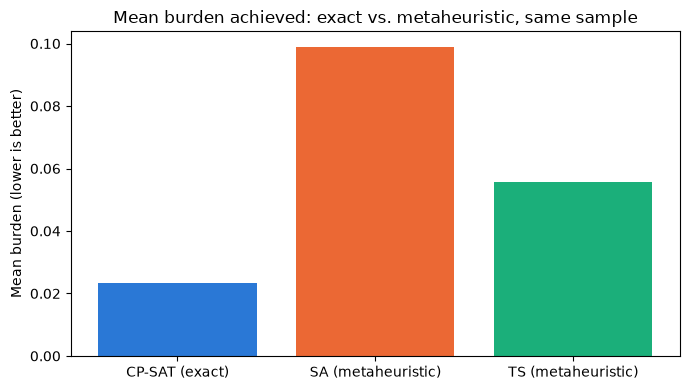

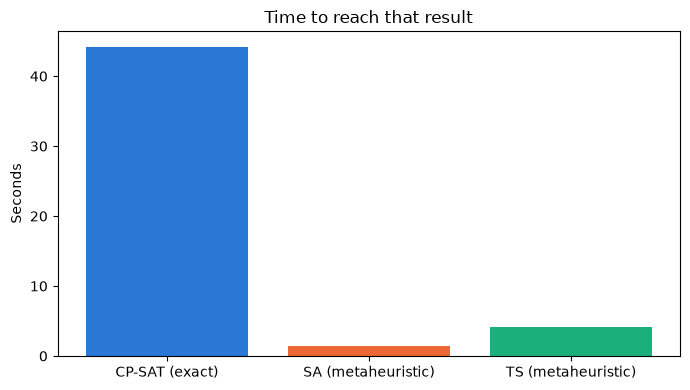

In [68]:
cp_mean = mean_check  # the independently-verified mean, not just the solver's own bookkeeping
comparison_rows = [
    {"Method": "CP-SAT (exact)", "Mean burden": round(cp_mean, 5),
     "Time to this result (s)": round(cp_stage1_time + cp_stage2_time, 1),
     "Proven optimal?": "Yes" if solver_stage2.StatusName(status2) == "OPTIMAL" else "Feasible only"},
    {"Method": "SA (metaheuristic)", "Mean burden": round(sa_result["mean"], 5),
     "Time to this result (s)": round(sa_feasible_time + sa_mean_time, 1), "Proven optimal?": "No guarantee"},
    {"Method": "TS (metaheuristic)", "Mean burden": round(ts_result["mean"], 5),
     "Time to this result (s)": round(ts_feasible_time + ts_mean_time, 1), "Proven optimal?": "No guarantee"},
]
comparison_df = pd.DataFrame(comparison_rows)
print(comparison_df.to_string(index=False))
print()
print("How to read this: CP-SAT's mean is the PROVEN best possible for this sample under "
      "this objective, nothing scores lower, that's what 'exact' means. SA and TS make no "
      "such guarantee, but the table shows directly how close they got, and how much faster.")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(comparison_df["Method"], comparison_df["Mean burden"], color=["#2a78d6", "#eb6834", "#1baf7a"])
ax.set_ylabel("Mean burden (lower is better)")
ax.set_title("Mean burden achieved: exact vs. metaheuristic, same sample")
plt.tight_layout()
plt.savefig("em_comparison_mean_burden.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(comparison_df["Method"], comparison_df["Time to this result (s)"], color=["#2a78d6", "#eb6834", "#1baf7a"])
ax.set_ylabel("Seconds")
ax.set_title("Time to reach that result")
plt.tight_layout()
plt.savefig("em_comparison_time.png", dpi=150)
plt.show()


## 13. Notes for next steps

- **`SAMPLE_SIZE = 8`** is a starting point sized around real measured timing for the
  *full* 8-profile objective (the pure feasibility check alone scales comfortably to
  20+), not a hard ceiling, raise it and see what happens, `SOLVE_TIME_LIMIT_SECONDS`
  is the other lever if you do.
- **Try a different `SAMPLE_SEED`** if you want a comparison where burden isn't
  trivially zero for everyone, this particular draw happened to sample tutors whose
  preferences were all comfortably satisfiable at once, a real, if unremarkable, result,
  not a bug, but not the most illustrative comparison either.
- **The ILP finding (Section 10)** is worth its own paragraph in the thesis: a
  correctly-linearized formulation that a commercial solver might handle fine, but that
  the available open-source backend could not, is a real, citable result about solver
  choice mattering as much as formulation correctness.
- **Everything reused from SA/TS was pulled verbatim**, not reimplemented from memory,
  the one adjustment (H1's completeness check) is clearly isolated and explained in
  Section 9, not silently baked into the original functions.
